Step 1 — Import pandas and load the CSV



In [1]:
import pandas as pd

df = pd.read_csv('/content/Salary_Data.csv')

df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


Step 2 — Check the dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  25 non-null     float64
 1   Salary           25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


Step 3 — Visualize the data 📊

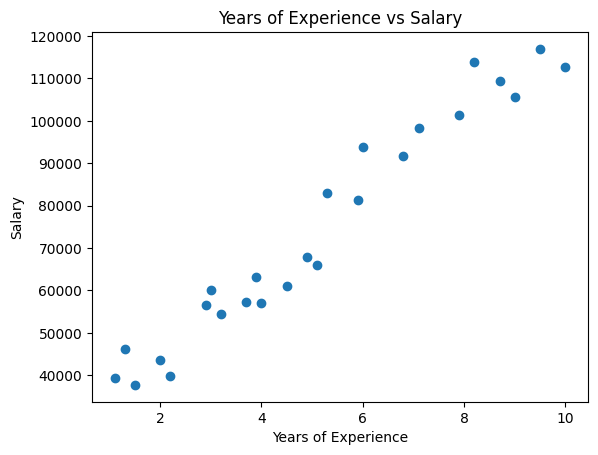

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['YearsExperience'], df['Salary'])

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')

plt.show()

Step 4 — Define X and y

In [4]:
X = df[['YearsExperience']]
y = df['Salary']

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2

y:
0    39343
1    46205
2    37731
3    43525
4    39891
Name: Salary, dtype: int64


Step 5 — Split the data

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (20, 1)
Testing data: (5, 1)


Step 6 — Create the Linear Regression model

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

Step 7 — Train the Linear Regression model

In [7]:
model.fit(X_train, y_train)

LinearRegression()

Step 8 — See what the model learned

In [8]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 26345.488852851864
Coefficient: 9359.040067472912


Step 9 — Predict the salaries

In [9]:
y_pred = model.predict(X_test)

print(y_pred)

[ 60973.9371025   82499.72925769  36640.43292707 115256.36949384
  68461.16915648]


Step 10 — Compare actual vs predicted

In [10]:
comparison = pd.DataFrame({
    'Years of Experience': X_test['YearsExperience'].values,
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

comparison

,Years of Experience,Actual Salary,Predicted Salary
0,3.7,57189,60973.937103
1,6.0,93940,82499.729258
2,1.1,39343,36640.432927
3,9.5,116969,115256.369494
4,4.5,61111,68461.169156


Step 11 — Calculate the prediction error

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 5398.114916075135
MSE: 41893500.43808418
RMSE: 6472.518863478435
R² Score: 0.9461988242637623


In [13]:
new_data = pd.DataFrame({
    'YearsExperience': [7]
})

prediction = model.predict(new_data)

print("Predicted Salary:", prediction[0])

Predicted Salary: 91858.76932516225


Step 12 — Plot the regression line

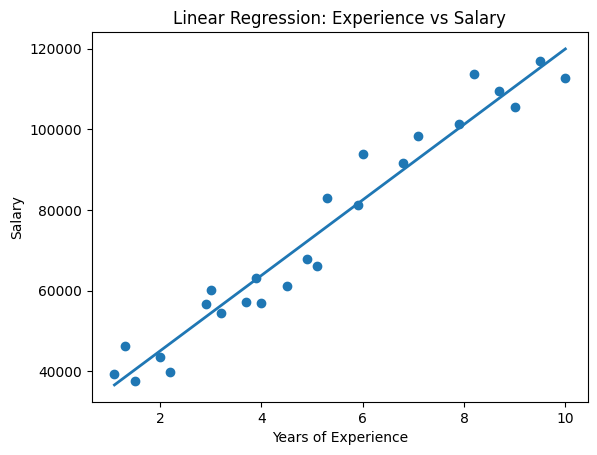

In [14]:
plt.scatter(X, y)

plt.plot(X, model.predict(X), linewidth=2)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Experience vs Salary")

plt.show()

Step 13 — Display the regression equation

In [15]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

print(
    f"Salary = {model.intercept_:.2f} + "
    f"({model.coef_[0]:.2f} × YearsExperience)"
)

Intercept: 26345.488852851864
Coefficient: 9359.040067472912
Salary = 26345.49 + (9359.04 × YearsExperience)


Step 14 — Test multiple new values

In [16]:
new_data = pd.DataFrame({
    'YearsExperience': [2, 5, 7, 10, 12]
})

predictions = model.predict(new_data)

result = pd.DataFrame({
    'YearsExperience': new_data['YearsExperience'],
    'PredictedSalary': predictions
})

result

,YearsExperience,PredictedSalary
0,2,45063.568988
1,5,73140.689190
2,7,91858.769325
3,10,119935.889528
4,12,138653.969663


Step 15 — Save your trained model

In [17]:
import joblib

joblib.dump(model, 'salary_linear_regression.pkl')

print("Model saved successfully!")

Model saved successfully!
